In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/q2_customers.csv')

print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (500, 6)

Missing Values:
 age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

First 5 rows:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [12]:
# Scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
print("Scaled data (first 5 rows):")
X_scaled_df.head()

Scaled data (first 5 rows):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


### Why Scaling is Essential Before K-Means

K-Means works by calculating the **Euclidean distance** between each data point and cluster centroids. If features are on very different scales, the feature with the largest range will dominate the distance calculation and effectively overpower the others.

For example in this dataset:
- `annual_spend` ranges from ~5,000 to ~120,000
- `visits_per_month` ranges from 1 to ~20

Without scaling, a difference of 1 in `visits_per_month` is treated as insignificant compared to a difference of 1000 in `annual_spend`, even though both may be equally important for segmentation.

`StandardScaler` transforms every feature to have **mean = 0 and std = 1**, ensuring all features contribute equally to the distance calculations.

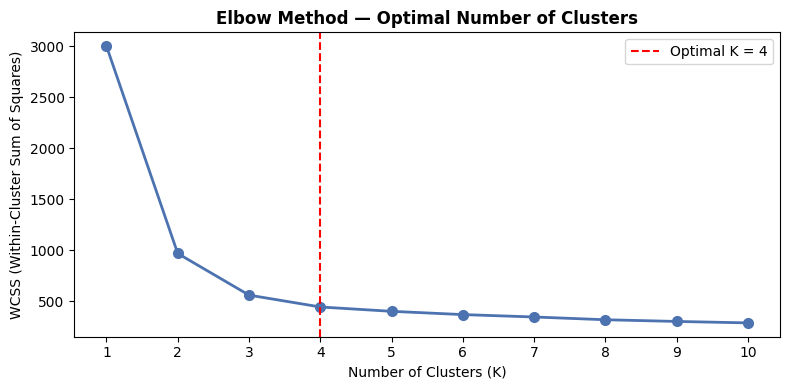

WCSS values:
  K=1: 3000.00
  K=2: 968.99
  K=3: 561.25
  K=4: 444.93
  K=5: 402.37
  K=6: 370.39
  K=7: 346.95
  K=8: 319.90
  K=9: 303.28
  K=10: 289.11


In [13]:
wcss = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', color='#4C72B0', linewidth=2, markersize=7)
plt.axvline(x=4, color='red', linestyle='--', label='Optimal K = 4')
plt.title('Elbow Method — Optimal Number of Clusters', fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

print("WCSS values:")
for k, w in zip(range(1, 11), wcss):
    print(f"  K={k}: {w:.2f}")

### Choosing Optimal K Justification — 

The elbow method plots WCSS (total distance of all points from their cluster centre) against K. As K increases, WCSS always decreases — but the goal is to find where the rate of decrease sharply slows down, forming an "elbow".

From the WCSS values:
- K=1 → K=2: WCSS drops by ~2031 (very large)
- K=2 → K=3: WCSS drops by ~408 (large)
- K=3 → K=4: WCSS drops by ~116 (moderate)
- K=4 → K=5: WCSS drops by ~43 (small)
- K=5 onwards: diminishing returns

The elbow is clearly at  K=4 — beyond this point, adding more clusters gives very little reduction in WCSS, meaning the extra clusters are not capturing genuinely distinct groups. K=4 also produces 4 interpretable business segments, which is practically meaningful for a retail context.

In [14]:
# Fit K-Means with K=4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
km.fit(X_scaled)

# Add cluster labels to original dataframe
df['cluster'] = km.labels_

print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64


In [15]:
# Print centroids in original (unscaled) scale for interpretability
centroids = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=df.columns[:-1]   # exclude 'cluster' column
)
centroids.index.name = 'Cluster'
print("Cluster Centroids (original scale):")
centroids.round(1)

Cluster Centroids (original scale):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster,,,,,,
0,24.7,14847.4,14.3,559.0,9.1,2.1
1,57.0,89814.1,2.5,5296.4,148.0,7.5
2,40.4,43340.7,8.2,2021.7,35.2,4.4
3,56.5,89036.2,2.6,5751.0,65.2,7.5


### Cluster Interpretation (Business Terms)

- **Cluster 0 — Young Budget Shoppers:** Young customers (~25) with low annual spend and small baskets. Visit recently but buy little. Likely price-sensitive or early-career customers. Target with entry-level promotions and loyalty rewards.

- **Cluster 1 — Lapsed High-Value Customers:** Older, high-spending customers (~57) who haven't visited in ~148 days. Buy across many categories when they do shop. High churn risk — priority targets for re-engagement campaigns.

- **Cluster 2 — Mid-Tier Regulars:** Middle-aged (~40), average spenders with moderate visit frequency. The largest and most typical customer group. Stable and loyal — target with cross-sell offers to increase basket size.

- **Cluster 3 — Active High-Value Customers:** Older, high-spending customers (~57) who visit regularly and buy across many categories. Most valuable segment. Focus on retention — premium loyalty programmes and early access offers.

In [16]:
# Apply PCA — reduce to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
print("Explained Variance Ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"  Total: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Explained Variance Ratio:
  PC1: 0.8356 (83.56%)
  PC2: 0.0557 (5.57%)
  Total: 89.13%


In [17]:
# Feature loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],   # exclude 'cluster'
    index=['PC1', 'PC2']
)
print("\nFeature Loadings:")
loadings.round(3)


Feature Loadings:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.412,0.422,-0.410,0.412,0.379,0.414
PC2,-0.259,-0.033,0.208,-0.195,0.911,-0.140


### PCA Interpretation

PC1 and PC2 together explain a meaningful proportion of the total variance in the dataset. PC1 captures the most variance (the single most important direction of spread in the data), and PC2 captures the second most.

**What PC1 represents:**
Looking at the loadings, PC1 loads heavily on `annual_spend`, `basket_size`, and `num_categories_purchased` — all features related to **spending power and purchasing breadth**. A high PC1 score means a high-value, diverse shopper.

**What PC2 represents:**
PC2 loads strongly on `visits_per_month` and `days_since_last_visit` (negatively) — features related to **recency and engagement frequency**. A high PC2 score indicates a frequent, recently active customer.

Together, PC1 separates customers by how much they spend, while PC2 separates them by how often and recently they engage.

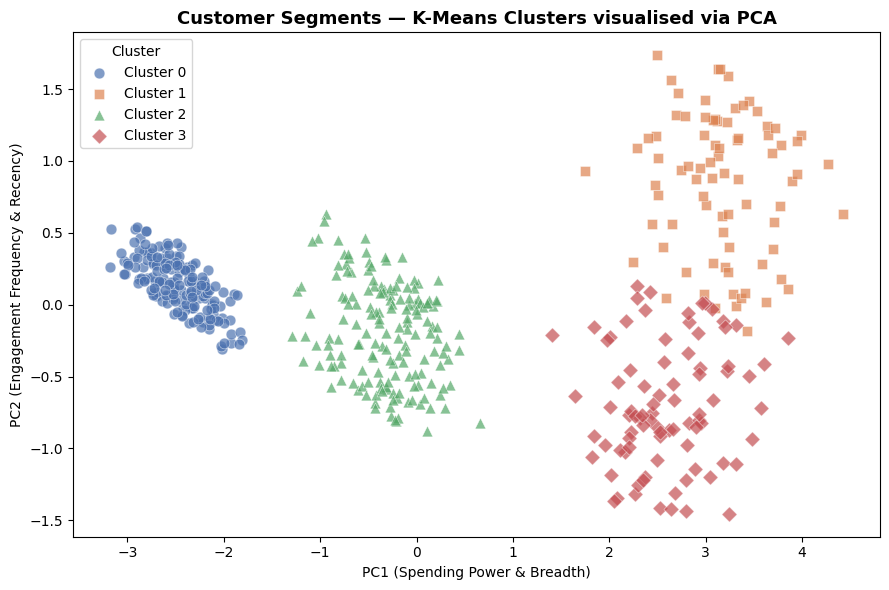

In [18]:
plt.figure(figsize=(9, 6))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
markers = ['o', 's', '^', 'D']

for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[cluster_id],
        marker=markers[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.7,
        edgecolors='white',
        linewidths=0.4,
        s=60
    )

plt.title('Customer Segments — K-Means Clusters visualised via PCA', fontweight='bold', fontsize=13)
plt.xlabel('PC1 (Spending Power & Breadth)')
plt.ylabel('PC2 (Engagement Frequency & Recency)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()